# import libraries


In [1]:
pip install seaborn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\sh\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

import os
from scipy.sparse import coo_matrix


In [3]:
df = pd.read_csv(r"C:\Users\sh\E-Commerece-Recommendation-System-Machine-Learning-Product-Recommendation-system\marketing_sample_for_walmart_com-walmart_com_product_review__20200701_20201231__5k_data.tsv" ,  sep='\t')

In [4]:
df.head(3)

,Uniq Id,Crawl Timestamp,Dataset Origin,Product Id,Product Barcode,Product Company Type Source,Product Brand Source,Product Brand Normalised Source,Product Name Source,Match Rank,...,Product Currency,Product Available Inventory,Product Image Url,Product Model Number,Product Tags,Product Contents,Product Rating,Product Reviews Count,Bsr,Joining Key
0,1705736792d82aa2f2d3caf1c07c53f4,2020-09-24 03:21:12 +0000,NaN,2e17bf4acecdece67fc00f07ad62c910,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,NaN,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",NaN,NaN,NaN,NaN,81350af1be98d3753cf964709f0c766a
1,95a9fe6f4810fcfc7ff244fd06784f11,2020-10-30 14:04:08 +0000,NaN,076e5854a62dd283c253d6bae415af1f,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/9c8e42e4-13a5...,NaN,"Nice 'n Easy Permanent Color, 111 Natural Medi...",NaN,NaN,NaN,NaN,0353e63907dc0de0c734db4690300057
2,8d4d0330178d3ed181b15a4102b287f2,2020-08-06 05:51:47 +0000,NaN,8a4fe5d9c7a6ed26cc44d785a454b124,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/e3a601c2-6a2b...,NaN,Clairol Nice 'N Easy Permanent Color 7/106A Na...,NaN,4.5,29221.0,NaN,b6985c8e94815fbca2319dbb8bf228af


In [5]:
df.tail(3)

,Uniq Id,Crawl Timestamp,Dataset Origin,Product Id,Product Barcode,Product Company Type Source,Product Brand Source,Product Brand Normalised Source,Product Name Source,Match Rank,...,Product Currency,Product Available Inventory,Product Image Url,Product Model Number,Product Tags,Product Contents,Product Rating,Product Reviews Count,Bsr,Joining Key
4997,34d1aa70845416c3df059a088aaf18dc,2020-12-01T02:02:32+00:00,NaN,96ed378fb9466b11abde8f9baea58844,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/d6202179-2c93...,NaN,"Nail File Electric Drill, 6 in 1 Professional ...",NaN,NaN,4.0,NaN,acf460a46f2b2967ee0b0a9ae3eff7dc
4998,ff9cfa22550bf036e2487a9100d927f1,2020-10-20 21:29:05 +0000,NaN,f7b05869f3ee7fe22864ea58cbb006d1,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/3dc99239-66d2...,NaN,Creed Love In Black Hair And Body Wash 6.8oz/2...,NaN,NaN,NaN,NaN,cd97ac9b2e21a81ea23e4bea58096df7
4999,0de862f8c1c4f23b6c4cfe59fd574b59,2020-11-12T10:54:32+00:00,NaN,1c9e4943fd915f7b016cdc593e607e02,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/a76122fd-322a...,NaN,"Foundation, Wal-mart, Walmart.com",NaN,NaN,438.0,NaN,69870b86f5ab30b15b025ca7a3489e39


In [6]:
df.columns

Index(['Uniq Id', 'Crawl Timestamp', 'Dataset Origin', 'Product Id',
       'Product Barcode', 'Product Company Type Source',
       'Product Brand Source', 'Product Brand Normalised Source',
       'Product Name Source', 'Match Rank', 'Match Score', 'Match Type',
       'Retailer', 'Product Category', 'Product Brand', 'Product Name',
       'Product Price', 'Sku', 'Upc', 'Product Url', 'Market',
       'Product Description', 'Product Currency',
       'Product Available Inventory', 'Product Image Url',
       'Product Model Number', 'Product Tags', 'Product Contents',
       'Product Rating', 'Product Reviews Count', 'Bsr', 'Joining Key'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Uniq Id                          5000 non-null   object 
 1   Crawl Timestamp                  5000 non-null   object 
 2   Dataset Origin                   0 non-null      float64
 3   Product Id                       5000 non-null   object 
 4   Product Barcode                  0 non-null      float64
 5   Product Company Type Source      5000 non-null   object 
 6   Product Brand Source             139 non-null    object 
 7   Product Brand Normalised Source  139 non-null    object 
 8   Product Name Source              139 non-null    object 
 9   Match Rank                       0 non-null      float64
 10  Match Score                      0 non-null      float64
 11  Match Type                       0 non-null      float64
 12  Retailer            

In [8]:
df.describe()

,Dataset Origin,Product Barcode,Match Rank,Match Score,Match Type,Product Price,Sku,Upc,Product Available Inventory,Product Model Number,Product Contents,Product Rating,Product Reviews Count,Bsr
count,0.0,0.0,0.0,0.0,0.0,4958.000000,0.0,0.0,5000.0,0.0,0.0,2194.000000,3346.000000,0.0
mean,NaN,NaN,NaN,NaN,NaN,23.364425,NaN,NaN,111111111.0,NaN,NaN,4.294622,571.035565,NaN
std,NaN,NaN,NaN,NaN,NaN,35.182204,NaN,NaN,0.0,NaN,NaN,0.773311,2485.699363,NaN
min,NaN,NaN,NaN,NaN,NaN,0.100000,NaN,NaN,111111111.0,NaN,NaN,1.000000,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,8.400000,NaN,NaN,111111111.0,NaN,NaN,4.000000,3.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,14.950000,NaN,NaN,111111111.0,NaN,NaN,4.500000,20.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,26.007500,NaN,NaN,111111111.0,NaN,NaN,4.800000,170.000000,NaN
max,NaN,NaN,NaN,NaN,NaN,722.450000,NaN,NaN,111111111.0,NaN,NaN,5.000000,29242.000000,NaN


In [9]:
df.isnull().sum()

Uniq Id                               0
Crawl Timestamp                       0
Dataset Origin                     5000
Product Id                            0
Product Barcode                    5000
Product Company Type Source           0
Product Brand Source               4861
Product Brand Normalised Source    4861
Product Name Source                4861
Match Rank                         5000
Match Score                        5000
Match Type                         5000
Retailer                              0
Product Category                     10
Product Brand                        13
Product Name                          0
Product Price                        42
Sku                                5000
Upc                                5000
Product Url                           0
Market                                0
Product Description                1127
Product Currency                      0
Product Available Inventory           0
Product Image Url                     0


In [10]:
# dfFill missing values in 'Dataset Origin' with an empty string
df['Dataset Origin'].fillna('', inplace=True)

# Fill missing values in 'Product Barcode' with an empty string
df['Product Barcode'].fillna('', inplace=True)

# Fill missing values in 'Product Brand Source' with an empty string
df['Product Brand Source'].fillna('', inplace=True)

# Fill missing values in 'Product Brand Normalised Source' with an empty string
df['Product Brand Normalised Source'].fillna('', inplace=True)

# Fill missing values in 'Product Name Source' with an empty string
df['Product Name Source'].fillna('', inplace=True)

# Fill missing values in 'Match Rank' with 0
df['Match Rank'].fillna(0, inplace=True)

# Fill missing values in 'Match Score' with 0
df['Match Score'].fillna(0, inplace=True)

# Fill missing values in 'Match Type' with an empty string
df['Match Type'].fillna('', inplace=True)

# Fill missing values in 'Product Category' with an empty string
df['Product Category'].fillna('', inplace=True)

# Fill missing values in 'Product Brand' with an empty string
df['Product Brand'].fillna('', inplace=True)

# Fill missing values in 'Product Price' with 0
df['Product Price'].fillna(0, inplace=True)

# Fill missing values in 'Product Description' with an empty string
df['Product Description'].fillna('', inplace=True)

# Fill missing values in 'Product Rating' with 0
df['Product Rating'].fillna(0, inplace=True)

# Fill missing values in 'Product Reviews Count' with 0
df['Product Reviews Count'].fillna(0, inplace=True)

# Fill missing values in 'Bsr' with 0
df['Bsr'].fillna(0, inplace=True)

C:\Users\sh\AppData\Local\Temp\ipykernel_55464\1716577005.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dataset Origin'].fillna('', inplace=True)
C:\Users\sh\AppData\Local\Temp\ipykernel_55464\1716577005.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['Dataset Origin'].fillna('', inplace=True)
C:\Users\sh\AppData\Local\Temp\ipykernel_554

In [11]:
df.isnull().sum()

Uniq Id                               0
Crawl Timestamp                       0
Dataset Origin                        0
Product Id                            0
Product Barcode                       0
Product Company Type Source           0
Product Brand Source                  0
Product Brand Normalised Source       0
Product Name Source                   0
Match Rank                            0
Match Score                           0
Match Type                            0
Retailer                              0
Product Category                      0
Product Brand                         0
Product Name                          0
Product Price                         0
Sku                                5000
Upc                                5000
Product Url                           0
Market                                0
Product Description                   0
Product Currency                      0
Product Available Inventory           0
Product Image Url                     0


In [12]:
df.drop(columns=['Sku', 'Upc'], inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
column_name_mapping = {
    'Uniq Id': 'ID',
    'Product Id': 'ProdID',
    'Product Rating': 'Rating',
    'Product Reviews Count': 'ReviewCount',
    'Product Category': 'Category',
    'Product Brand': 'Brand',
    'Product Name': 'Name',
    'Product Image Url': 'ImageURL',
    'Product Description': 'Description',
    'Product Tags': 'Tags',
    'Product Contents': 'Contents'
}

In [15]:
df.rename(columns=column_name_mapping , inplace=True)

In [16]:
df['ID'] = df['ID'].str.extract(r'(\d+)').astype(float)
df['ProdID'] = df['ProdID'].str.extract(r'(\d+)').astype(float)

In [17]:
df.head()

,ID,Crawl Timestamp,Dataset Origin,ProdID,Product Barcode,Product Company Type Source,Product Brand Source,Product Brand Normalised Source,Product Name Source,Match Rank,...,Product Currency,Product Available Inventory,ImageURL,Product Model Number,Tags,Contents,Rating,ReviewCount,Bsr,Joining Key
0,1.705737e+09,2020-09-24 03:21:12 +0000,,2.0,,Competitor,,,,0.0,...,USD,111111111,https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,NaN,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",NaN,0.0,0.0,0.0,81350af1be98d3753cf964709f0c766a
1,9.500000e+01,2020-10-30 14:04:08 +0000,,76.0,,Competitor,,,,0.0,...,USD,111111111,https://i5.walmartimages.com/asr/9c8e42e4-13a5...,NaN,"Nice 'n Easy Permanent Color, 111 Natural Medi...",NaN,0.0,0.0,0.0,0353e63907dc0de0c734db4690300057
2,8.000000e+00,2020-08-06 05:51:47 +0000,,8.0,,Competitor,,,,0.0,...,USD,111111111,https://i5.walmartimages.com/asr/e3a601c2-6a2b...,NaN,Clairol Nice 'N Easy Permanent Color 7/106A Na...,NaN,4.5,29221.0,0.0,b6985c8e94815fbca2319dbb8bf228af
3,4.000000e+00,2020-07-15 11:22:04 +0000,,3.0,,Competitor,,,,0.0,...,USD,111111111,https://i5.walmartimages.com/asr/25b4b467-bc61...,NaN,"Kokie Professional Matte Lipstick, Hot Berry, ...",NaN,0.0,0.0,0.0,85b70fded09186f00467cea2f935b779
4,9.900000e+02,2020-11-26T12:27:20+00:00,,3.0,,Competitor,,,,0.0,...,USD,111111111,https://i5.walmartimages.com/asr/1a2ebb06-cd01...,NaN,"Gillette TRAC II Plus Razor Blade Refills, Fit...",NaN,0.0,131.0,0.0,41c870871328e97da6fb036bb7d4b2da


In [18]:
# Basic statistics
num_users = df['ID'].nunique()
num_items = df['ProdID'].nunique()
num_ratings = df['Rating'].nunique()
print(f"Number of unique users: {num_users}")
print(f"Number of unique items: {num_items}")
print(f"Number of unique ratings: {num_ratings}")

Number of unique users: 1721
Number of unique items: 1697
Number of unique ratings: 36


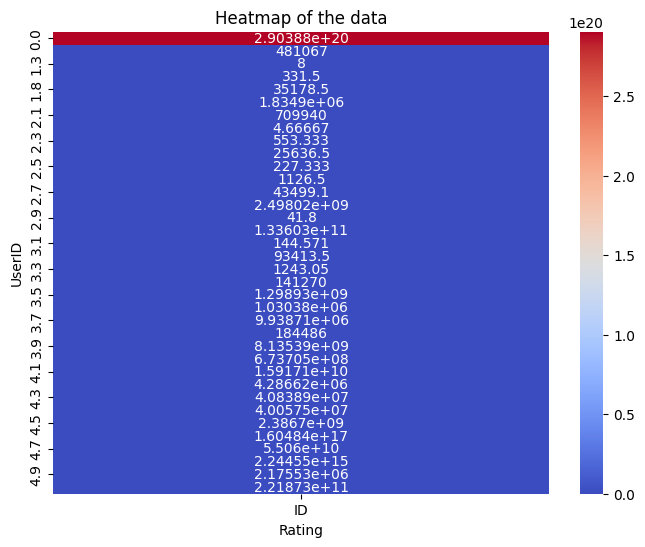

In [19]:
# pivot
heatmap_data = df.pivot_table('ID' , 'Rating')
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data , annot=True ,fmt = 'g' , cmap= "coolwarm" , cbar= True )
plt.title("Heatmap of the data")
plt.xlabel("Rating")
plt.ylabel("UserID")
plt.show()

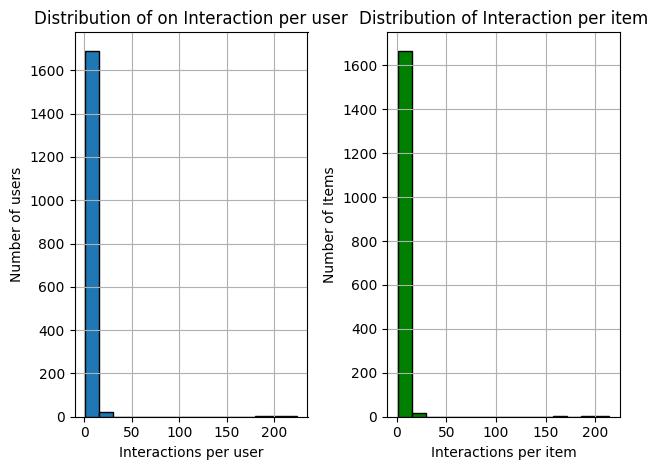

In [20]:
# Distribution
plt.Figure(figsize=(12,5))
plt.subplot(1 , 2 , 1)
df["ID"].value_counts().hist(bins= 15 , edgecolor = 'k')
plt.xlabel("Interactions per user")
plt.ylabel("Number of users")
plt.title("Distribution of on Interaction per user")

plt.subplot(1 , 2 , 2)
df["ProdID"].value_counts().hist(bins = 15 , edgecolor = 'k' , color = "green")
plt.xlabel("Interactions per item")
plt.ylabel("Number of Items")
plt.title("Distribution of Interaction per item")
plt.tight_layout()
plt.show()

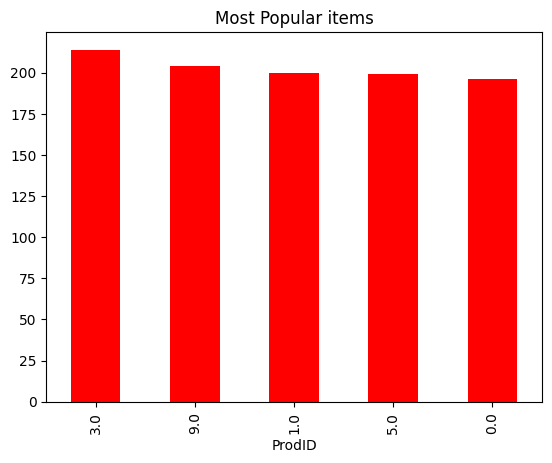

In [21]:
popular_items = df['ProdID'].value_counts().head(5)
popular_items.plot(kind = 'bar' , color = "red")
plt.title("Most Popular items")
plt.show()

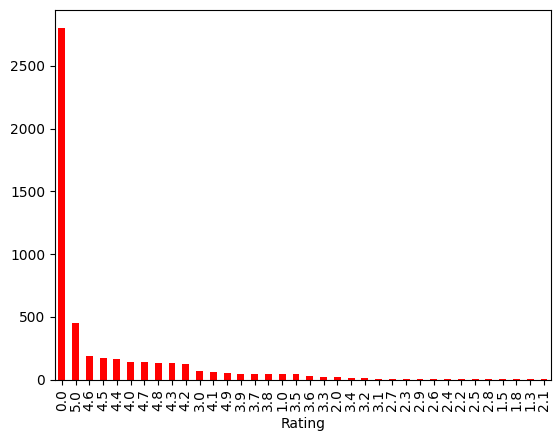

In [22]:
df['Rating'].value_counts().plot(kind='bar' , color = 'red')
plt.show()

# clean data

In [23]:
pip install spacy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\sh\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [24]:
!python -m spacy download en_core_web_sm

C:\Users\sh\E-Commerece-Recommendation-System-Machine-Learning-Product-Recommendation-system\.venv\Scripts\python.exe: No module named spacy


In [25]:
from spacy import load
nlp = load('en_core_web_sm')
nlp.disable_pipe('ner')
import re

C:\Users\sh\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [26]:
def process_text(text: str):
    # Process text using spaCy
    doc = nlp(str(text))

    # Remove Stop Words
    words = [word for word in doc if not word.is_stop]

    # Remove all single characters
    words = [word for word in words if len(word.text) > 1]

    # Lemmatization
    words = [word.lemma_ for word in words]

    # Convert to lowercase
    clean_text = ' '.join(words).lower()

    return clean_text


columns_to_extract_tags_from = ['Category', 'Brand', 'Description']

for column in columns_to_extract_tags_from:
    df[column] = df[column].apply(process_text)

In [27]:
df.head()

,ID,Crawl Timestamp,Dataset Origin,ProdID,Product Barcode,Product Company Type Source,Product Brand Source,Product Brand Normalised Source,Product Name Source,Match Rank,...,Product Currency,Product Available Inventory,ImageURL,Product Model Number,Tags,Contents,Rating,ReviewCount,Bsr,Joining Key
0,1.705737e+09,2020-09-24 03:21:12 +0000,,2.0,,Competitor,,,,0.0,...,USD,111111111,https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,NaN,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",NaN,0.0,0.0,0.0,81350af1be98d3753cf964709f0c766a
1,9.500000e+01,2020-10-30 14:04:08 +0000,,76.0,,Competitor,,,,0.0,...,USD,111111111,https://i5.walmartimages.com/asr/9c8e42e4-13a5...,NaN,"Nice 'n Easy Permanent Color, 111 Natural Medi...",NaN,0.0,0.0,0.0,0353e63907dc0de0c734db4690300057
2,8.000000e+00,2020-08-06 05:51:47 +0000,,8.0,,Competitor,,,,0.0,...,USD,111111111,https://i5.walmartimages.com/asr/e3a601c2-6a2b...,NaN,Clairol Nice 'N Easy Permanent Color 7/106A Na...,NaN,4.5,29221.0,0.0,b6985c8e94815fbca2319dbb8bf228af
3,4.000000e+00,2020-07-15 11:22:04 +0000,,3.0,,Competitor,,,,0.0,...,USD,111111111,https://i5.walmartimages.com/asr/25b4b467-bc61...,NaN,"Kokie Professional Matte Lipstick, Hot Berry, ...",NaN,0.0,0.0,0.0,85b70fded09186f00467cea2f935b779
4,9.900000e+02,2020-11-26T12:27:20+00:00,,3.0,,Competitor,,,,0.0,...,USD,111111111,https://i5.walmartimages.com/asr/1a2ebb06-cd01...,NaN,"Gillette TRAC II Plus Razor Blade Refills, Fit...",NaN,0.0,131.0,0.0,41c870871328e97da6fb036bb7d4b2da


In [28]:
# Concatenate the cleaned tags from all relevant columns
df['Tags'] = df[columns_to_extract_tags_from].apply(lambda row: ', '.join(row), axis=1)

In [29]:
average_ratings = df.groupby(['Name','ReviewCount','Brand','ImageURL'])['Rating'].mean().reset_index()

In [30]:
top_rated_items = average_ratings.sort_values(by = 'Rating' ,ascending = False)

rating_base_recommendation = top_rated_items.head(10)

In [31]:
rating_base_recommendation['Rating'] = rating_base_recommendation['Rating'].astype(int)
rating_base_recommendation['ReviewCount'] = rating_base_recommendation['ReviewCount'].astype(int)

C:\Users\sh\AppData\Local\Temp\ipykernel_55464\565725879.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rating_base_recommendation['Rating'] = rating_base_recommendation['Rating'].astype(int)
C:\Users\sh\AppData\Local\Temp\ipykernel_55464\565725879.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rating_base_recommendation['ReviewCount'] = rating_base_recommendation['ReviewCount'].astype(int)


In [32]:
print("Rating Base Recommendation System: (Trending Products)")
rating_base_recommendation[['Name','Rating','ReviewCount','Brand','ImageURL']] = rating_base_recommendation[['Name','Rating','ReviewCount','Brand','ImageURL']]
rating_base_recommendation

Rating Base Recommendation System: (Trending Products)


C:\Users\sh\AppData\Local\Temp\ipykernel_55464\393183274.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rating_base_recommendation[['Name','Rating','ReviewCount','Brand','ImageURL']] = rating_base_recommendation[['Name','Rating','ReviewCount','Brand','ImageURL']]


,Name,ReviewCount,Brand,ImageURL,Rating
1,($100 Value) Peter Thomas Roth Thermal Therapy...,1,peter thomas roth,https://i5.walmartimages.com/asr/ecd851ef-6ca7...,5
4959,got2b Kinkier Curling Mousse 8 oz (Pack of 2),1,göt2b,https://i5.walmartimages.com/asr/9e656b95-79f6...,5
6,($14 Value) Burts Bees Beeswax Bounty Classic ...,10,burt bee,https://i5.walmartimages.com/asr/bfbb58dc-8199...,5
1208,Clairol Professional Beautiful Collection Semi...,1,clairol,https://i5.walmartimages.com/asr/31562542-b683...,5
1216,"Clairol Textures & Tones 4RC Cherrywood, 1 ea ...",1,clairol,https://i5.walmartimages.com/asr/78f33717-0104...,5
1228,Clay-Park Labs Ammonium Lactate Lotion 12% 14 ...,13,clay park labs,https://i5.walmartimages.com/asr/b3d5462d-d067...,5
4857,"Yosoo Reusable Sanitary Pads with Wings, 9 Typ...",1,yosoo,https://i5.walmartimages.com/asr/5645ee43-e26f...,5
4862,ZINSSER & CO Jomax 1-Qt. Mold & Mildew Stain R...,1,jomax,https://i5.walmartimages.com/asr/d04c8d61-023a...,5
4892,"all Free Clear For Sensitive Skin, 110 Loads, ...",4,,https://i5.walmartimages.com/asr/9ccd3c7b-f479...,5
33,($55 Value) Clarins Multi-Active Day Face Crea...,2,clarins,https://i5.walmartimages.com/asr/894b62ab-76d2...,5


# Content Base Recommendation system (User Preferences or Items similarities)

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix_content = tfidf_vectorizer.fit_transform(df['Tags'])
cosine_similarities_content = cosine_similarity(tfidf_matrix_content,tfidf_matrix_content)

In [34]:
item_name = 'OPI Infinite Shine, Nail Lacquer Nail Polish, Bubble Bath'
item_index = df[df['Name']==item_name].index[0]

In [35]:
similar_items = list(enumerate(cosine_similarities_content[item_index]))

In [36]:
similar_items = sorted(similar_items  , key = lambda x:x[1] , reverse = True)
top_similar_items = similar_items[1:10]
recommended_item_indics = [x[0] for x in top_similar_items]

In [37]:
df.iloc[recommended_item_indics][['Name' , 'ReviewCount' , 'Brand']]

,Name,ReviewCount,Brand
156,OPI Nail Lacquer Polish .5oz/15mL - This Gown ...,0.0,opi
184,OPI Nail Gel Polish GelColor .5oz/15mL 3 CT Co...,0.0,opi
205,OPI Nail Lacquer - Dont Bossa Nova Me Around -...,0.0,opi
237,OPI Infinite Shine 2 Polish - ISL P33 - Alpaca...,5.0,opi
325,OPI Gel Polish Fall 2019 Scotland Collection G...,1.0,opi
375,OPI Nail Gel Polish GelColor .5oz/15mL 3 CT Co...,1.0,opi
402,"OPI Nail Polish, Strawberry Margarita, 0.5 Fl Oz",57.0,opi
706,OPI Nail Gel Polish GelColor .5oz/15mL 3 CT Co...,1.0,opi
886,OPI- Nail Lacquer-GelColor - &quotLiv&quotin t...,0.0,opi


# Function To Recommend Products for Content Base

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
def content_based_recommendations(df , item_name , top_n = 10):
    if item_name not in df['Name'].values:
        print(f"item '{item_name}' not found in the training_data")
        return pd.DataFrame()

    
    # Create a TF-IDF vectorizer for item descriptions
    tfidf_vectorizer = TfidfVectorizer(stop_words='english')

    # Apply TF-IDF vectorization to item descriptions
    tfidf_matrix_content = tfidf_vectorizer.fit_transform(df['Tags'])

    # Calculate cosine similarity between items based on descriptions
    cosine_similarities_content = cosine_similarity(tfidf_matrix_content, tfidf_matrix_content)

    # Find the index of the item
    item_index = df[df['Name'] == item_name].index[0]

    # Get the cosine similarity scores for the item
    similar_items = list(enumerate(cosine_similarities_content[item_index]))

    # Sort similar items by similarity score in descending order
    similar_items = sorted(similar_items, key=lambda x: x[1], reverse=True)

    # Get the top N most similar items (excluding the item itself)
    top_similar_items = similar_items[1:top_n+1]

    # Get the indices of the top similar items
    recommended_item_indices = [x[0] for x in top_similar_items]

    # Get the details of the top similar items
    recommended_items_details = df.iloc[recommended_item_indices][['Name', 'ReviewCount', 'Brand', 'ImageURL', 'Rating']]

    return recommended_items_details



In [39]:
# Example: Get content-based recommendations for a specific item
item_name = 'OPI Infinite Shine, Nail Lacquer Nail Polish, Bubble Bath'
content_based_rec = content_based_recommendations(df, item_name, top_n=8)

content_based_rec

,Name,ReviewCount,Brand,ImageURL,Rating
156,OPI Nail Lacquer Polish .5oz/15mL - This Gown ...,0.0,opi,https://i5.walmartimages.com/asr/71caed3f-5f83...,0.0
184,OPI Nail Gel Polish GelColor .5oz/15mL 3 CT Co...,0.0,opi,https://i5.walmartimages.com/asr/2d6f5147-53a8...,0.0
205,OPI Nail Lacquer - Dont Bossa Nova Me Around -...,0.0,opi,https://i5.walmartimages.com/asr/fd1195d2-8d8d...,0.0
237,OPI Infinite Shine 2 Polish - ISL P33 - Alpaca...,5.0,opi,https://i5.walmartimages.com/asr/7426eb5c-1690...,0.0
325,OPI Gel Polish Fall 2019 Scotland Collection G...,1.0,opi,https://i5.walmartimages.com/asr/79bbbd9f-9a89...,0.0
375,OPI Nail Gel Polish GelColor .5oz/15mL 3 CT Co...,1.0,opi,https://i5.walmartimages.com/asr/744e869c-3500...,5.0
402,"OPI Nail Polish, Strawberry Margarita, 0.5 Fl Oz",57.0,opi,https://i5.walmartimages.com/asr/b95676e5-96ab...,4.4
706,OPI Nail Gel Polish GelColor .5oz/15mL 3 CT Co...,1.0,opi,https://i5.walmartimages.com/asr/c7ba4815-52f7...,5.0


In [40]:
item_name = 'Kokie Professional Matte Lipstick, Hot Berry, 0.14 fl oz'
content_based_rec = content_based_recommendations(df , item_name , top_n=8)
content_based_rec

,Name,ReviewCount,Brand,ImageURL,Rating
3406,"Kokie Professional Matte Lipstick, Firecracker...",0.0,kokie cosmetics,https://i5.walmartimages.com/asr/8312221b-ed22...,0.0
546,"Kokie Professional Matte Lipstick, Kiss Me, 0....",0.0,kokie cosmetics,https://i5.walmartimages.com/asr/27dd82a2-2b9c...,0.0
4050,Kokie Professional Lip Poudre Liquid Matte Liq...,7.0,kokie cosmetics,https://i5.walmartimages.com/asr/fdd7498c-319f...,3.4
2406,"L.A. Colors Matte Lipstick, Tender Matte",3.0,l.a. colors,https://i5.walmartimages.com/asr/271264fb-e8c3...,3.7
2873,Kokie Professional Lip Poudre Liquid Matte Liq...,7.0,kokie cosmetics,https://i5.walmartimages.com/asr/31c99d9b-ea11...,3.4
4872,"L.A. Colors Matte Lipstick, Torrid Matte",8.0,l.a. colors,https://i5.walmartimages.com/asr/62d6d9fa-eee1...,4.8
1559,"LOreal Paris Colour Riche Matte Lip Liner, Mat...",495.0,l'oreal paris,https://i5.walmartimages.com/asr/baf97085-7231...,4.4
420,Black Opal Color Splurge Sassy Luxe Matte Lips...,0.0,black opal,https://i5.walmartimages.com/asr/a991241b-e4ad...,0.0


# Collaborative Filtering (User Item Similarity)

In [41]:
user_item_matrix = df.pivot_table(index='ID', columns='ProdID', values='Rating',aggfunc='mean').fillna(0).astype(int)


In [42]:
user_similarity = cosine_similarity(user_item_matrix)

In [43]:
target_user_id = 4
target_user_index = user_item_matrix.index.get_loc(target_user_id)

In [44]:
user_similarities = user_similarity[target_user_index]
similar_user_indics = user_similarities.argsort()[::-1][1:]

In [45]:
recommend_items = []
for user_index in similar_user_indics:
    rated_by_similar_user = user_item_matrix.iloc[user_index]
    not_rated_by_target_user = (rated_by_similar_user==0) & (user_item_matrix.iloc[target_user_index]==0)
    recommend_items.extend(user_item_matrix.columns[not_rated_by_target_user][:10])

recommended_items_details = df[df['ProdID'].isin(recommend_items)][['Name','ReviewCount','Brand','ImageURL','Rating']]

In [46]:

recommended_items_details.head(10)

,Name,ReviewCount,Brand,ImageURL,Rating
15,Clairol Natural Instincts Demi-Permanent Hair ...,2935.0,clairol,https://i5.walmartimages.com/asr/00a6e54a-e431...,3.7
33,"DenTek Kids Fun Flossers, Removes Food & Plaqu...",3.0,dentek,https://i5.walmartimages.com/asr/de6e52eb-6e18...,0.0
61,"COVERGIRL Exhibitionist Cream Lipstick, 395 Da...",713.0,covergirl,https://i5.walmartimages.com/asr/95076ec0-ffbd...,4.3
64,Neutrogena SkinClearing Oil-Free Liquid Founda...,741.0,neutrogena,https://i5.walmartimages.com/asr/fd4d78d8-310a...,4.2
69,Design Essentials Natural Coconut & Monoi Curl...,1.0,design essentials,https://i5.walmartimages.com/asr/ff2dba1d-0c02...,5.0
78,"Paul Sebastian Fine Cologne Spray, Cologne for...",28.0,paul sebastian,https://i5.walmartimages.com/asr/03d08a07-18d7...,4.8
85,"BioAstin Hawaiian Astaxanthin, Vegan, 12mg, 75 Ct",3.0,bioastin,https://i5.walmartimages.com/asr/6da9e238-b19e...,5.0
92,"Bytewise Organic Moringa Leaf Powder, 12 Oz",0.0,bytewise,https://i5.walmartimages.com/asr/076f2b3f-fdc3...,0.0
94,Ag Hair Cosmetics Ultradynamics Extra-Firm Fin...,0.0,ag hair,https://i5.walmartimages.com/asr/5d217d98-a385...,0.0
108,OPI Nail Dipping Powder Perfection Combo - Liq...,1.0,opi,https://i5.walmartimages.com/asr/ef1607ee-5bdb...,3.0


# Function That Recommend Items

In [47]:
def collaborative_filtering_recommendations(df, target_user_id, top_n=10):
    # Create the user-item matrix
    user_item_matrix = df.pivot_table(index='ID', columns='ProdID', values='Rating', aggfunc='mean').fillna(0)

    # Calculate the user similarity matrix using cosine similarity
    user_similarity = cosine_similarity(user_item_matrix)

    # Find the index of the target user in the matrix
    target_user_index = user_item_matrix.index.get_loc(target_user_id)

    # Get the similarity scores for the target user
    user_similarities = user_similarity[target_user_index]

    # Sort the users by similarity in descending order (excluding the target user)
    similar_users_indices = user_similarities.argsort()[::-1][1:]

    # Generate recommendations based on similar users
    recommended_items = []

    for user_index in similar_users_indices:
        # Get items rated by the similar user but not by the target user
        rated_by_similar_user = user_item_matrix.iloc[user_index]
        not_rated_by_target_user = (rated_by_similar_user == 0) & (user_item_matrix.iloc[target_user_index] == 0)

        # Extract the item IDs of recommended items
        recommended_items.extend(user_item_matrix.columns[not_rated_by_target_user][:top_n])

    # Get the details of recommended items
    recommended_items_details = df[df['ProdID'].isin(recommended_items)][['Name', 'ReviewCount', 'Brand', 'ImageURL', 'Rating']]

    return recommended_items_details.head(10)

# Example usage
target_user_id = 4
top_n = 5
collaborative_filtering_rec = collaborative_filtering_recommendations(df, target_user_id)
print(f"Top {top_n} recommendations for User {target_user_id}:")
collaborative_filtering_rec

Top 5 recommendations for User 4:


,Name,ReviewCount,Brand,ImageURL,Rating
61,"COVERGIRL Exhibitionist Cream Lipstick, 395 Da...",713.0,covergirl,https://i5.walmartimages.com/asr/95076ec0-ffbd...,4.3
85,"BioAstin Hawaiian Astaxanthin, Vegan, 12mg, 75 Ct",3.0,bioastin,https://i5.walmartimages.com/asr/6da9e238-b19e...,5.0
86,LOreal Paris Feria Multi-Faceted Shimmering Pe...,2144.0,l'oreal paris,https://i5.walmartimages.com/asr/c229026a-2b75...,3.1
108,OPI Nail Dipping Powder Perfection Combo - Liq...,1.0,opi,https://i5.walmartimages.com/asr/ef1607ee-5bdb...,3.0
144,Covidien Curity Maternity Pad Heavy 4.33&quot ...,0.0,covidien,https://i5.walmartimages.com/asr/e4e38217-ed43...,0.0
155,"Crest 3D White Brilliance Mouthwash, Alcohol F...",63.0,crest,https://i5.walmartimages.com/asr/1fcc5525-9ae3...,0.0
174,COVERGIRL Outlast All-Day Moisturizing Lip Col...,36.0,covergirl,https://i5.walmartimages.com/asr/4479896f-c6c4...,0.0
193,"Revlon ColorStay Skinny Liquid Liner, 304 Gree...",70.0,revlon,https://i5.walmartimages.com/asr/aa3b20a6-3d6d...,4.5
212,"Comvita Certified UMF 20+ Manuka Honey, Raw & ...",0.0,comvita,https://i5.walmartimages.com/asr/3cdc1498-a2ac...,0.0
241,"Ahava Mens Mineral Hand Cream, 3.4 Oz",0.0,ahava,https://i5.walmartimages.com/asr/f74e4bb7-47d3...,0.0


# Hybrid Recommendations


In [48]:
# Hybrid Recommendations (Combine Content-Based and Collaborative Filtering)
def hybrid_recommendations(train_data,target_user_id, item_name, top_n=10):
    # Get content-based recommendations
    content_based_rec = content_based_recommendations(train_data,item_name, top_n)

    # Get collaborative filtering recommendations
    collaborative_filtering_rec = collaborative_filtering_recommendations(train_data,target_user_id, top_n)
    
    # Merge and deduplicate the recommendations
    hybrid_rec = pd.concat([content_based_rec, collaborative_filtering_rec]).drop_duplicates()
    
    return hybrid_rec.head(10)

In [49]:
# Example usage: Get hybrid recommendations for a specific user and item
target_user_id = 4 # Change this to the user_id you want recommendations for
item_name = "OPI Nail Lacquer Polish .5oz/15mL - This Gown Needs A Crown NL U11"  # Change this to the item name
hybrid_rec = hybrid_recommendations(df,target_user_id, item_name, top_n=10)

print(f"Top 10 Hybrid Recommendations for User {target_user_id} and Item '{item_name}':")
hybrid_rec

Top 10 Hybrid Recommendations for User 4 and Item 'OPI Nail Lacquer Polish .5oz/15mL - This Gown Needs A Crown NL U11':


,Name,ReviewCount,Brand,ImageURL,Rating
156,OPI Nail Lacquer Polish .5oz/15mL - This Gown ...,0.0,opi,https://i5.walmartimages.com/asr/71caed3f-5f83...,0.0
184,OPI Nail Gel Polish GelColor .5oz/15mL 3 CT Co...,0.0,opi,https://i5.walmartimages.com/asr/2d6f5147-53a8...,0.0
205,OPI Nail Lacquer - Dont Bossa Nova Me Around -...,0.0,opi,https://i5.walmartimages.com/asr/fd1195d2-8d8d...,0.0
237,OPI Infinite Shine 2 Polish - ISL P33 - Alpaca...,5.0,opi,https://i5.walmartimages.com/asr/7426eb5c-1690...,0.0
325,OPI Gel Polish Fall 2019 Scotland Collection G...,1.0,opi,https://i5.walmartimages.com/asr/79bbbd9f-9a89...,0.0
375,OPI Nail Gel Polish GelColor .5oz/15mL 3 CT Co...,1.0,opi,https://i5.walmartimages.com/asr/744e869c-3500...,5.0
402,"OPI Nail Polish, Strawberry Margarita, 0.5 Fl Oz",57.0,opi,https://i5.walmartimages.com/asr/b95676e5-96ab...,4.4
706,OPI Nail Gel Polish GelColor .5oz/15mL 3 CT Co...,1.0,opi,https://i5.walmartimages.com/asr/c7ba4815-52f7...,5.0
886,OPI- Nail Lacquer-GelColor - &quotLiv&quotin t...,0.0,opi,https://i5.walmartimages.com/asr/98b4194c-e026...,0.0
1042,"OPI GelColor Gel Nail Polish, Dulce De Leche, ...",1.0,opi,https://i5.walmartimages.com/asr/c1b2c370-b2d2...,0.0


In [50]:
# Example usage: Get hybrid recommendations for a specific user and item
target_user_id = 10 # Change this to the user_id you want recommendations for
item_name = 'Black Radiance Perfect Tone Matte Lip Crème, Succulent Plum'

hybrid_rec = hybrid_recommendations(df,target_user_id, item_name, top_n=10)

print(f"Top 10 Hybrid Recommendations for User {target_user_id} and Item '{item_name}':")
hybrid_rec

Top 10 Hybrid Recommendations for User 10 and Item 'Black Radiance Perfect Tone Matte Lip Crème, Succulent Plum':


,Name,ReviewCount,Brand,ImageURL,Rating
896,"Black Radiance Perfect Tone Lip Color, Vintage...",78.0,black radiance,https://i5.walmartimages.com/asr/485f26b4-a19a...,4.7
2496,"Black Radiance Perfect Tone Lip Color, Hollywo...",18.0,black radiance,https://i5.walmartimages.com/asr/fe3da48f-5142...,4.3
2873,Kokie Professional Lip Poudre Liquid Matte Liq...,7.0,kokie cosmetics,https://i5.walmartimages.com/asr/31c99d9b-ea11...,3.4
3,"Kokie Professional Matte Lipstick, Hot Berry, ...",0.0,kokie cosmetics,https://i5.walmartimages.com/asr/25b4b467-bc61...,0.0
3406,"Kokie Professional Matte Lipstick, Firecracker...",0.0,kokie cosmetics,https://i5.walmartimages.com/asr/8312221b-ed22...,0.0
3206,"Revlon Ultra HD Vinyl Lip Polish, Liquid Lipst...",2039.0,revlon,https://i5.walmartimages.com/asr/4d4c21d8-da3c...,0.0
4050,Kokie Professional Lip Poudre Liquid Matte Liq...,7.0,kokie cosmetics,https://i5.walmartimages.com/asr/fdd7498c-319f...,3.4
1240,Maybelline Color Sensational Elixir Lip Lacque...,0.0,maybelline,https://i5.walmartimages.com/asr/b80007ae-f2d9...,0.0
420,Black Opal Color Splurge Sassy Luxe Matte Lips...,0.0,black opal,https://i5.walmartimages.com/asr/a991241b-e4ad...,0.0
1300,"e.l.f. Liquid Matte Lipstick, Tea Rose",476.0,e.l.f cosmetic,https://i5.walmartimages.com/asr/58220de4-3875...,4.1
